In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns
from glob import glob

Initial climate inidices analysis

In [2]:
#Import and concat data
clim_files = glob('./data/processed/*.csv')

clim_dat = pd.DataFrame()
for file in clim_files:
    temp = pd.read_csv(file)
    clim_dat = pd.concat([clim_dat, temp])

#reshape data
clim_dat_wide = clim_dat.pivot(index = ['site', 'doy', 'lat', 'lon'], columns = ['variable']).reset_index()
clim_dat_wide.columns = ['_'.join(map(str, col)).strip('_') for col in clim_dat_wide.columns.values]

In [3]:
#Conversions 
#farenheit to C
clim_dat_wide['value_maxTemp_C'] = 5/9*(clim_dat_wide['value_maxTemp_F'] - 32)
clim_dat_wide['value_minTemp_C'] = 5/9*(clim_dat_wide['value_minTemp_F'] - 32)
clim_dat_wide['value_meanTemp_C'] = 0.5*(clim_dat_wide['value_maxTemp_F'] + clim_dat_wide['value_minTemp_F'])

#precip in to cm
clim_dat_wide['value_precip_cm'] = 2.54*(clim_dat_wide['value_precip_cum'])


In [4]:
clim_dat_wide.head()

,site,doy,lat,lon,value_maxTemp_F,value_minTemp_F,value_precip_cum,value_maxTemp_C,value_minTemp_C,value_meanTemp_C,value_precip_cm
0,ASH,2.0,46.050133,-95.87849,20.885697,-16.552516,0.036912,-6.174613,-26.973620,2.166591,0.093756
1,ASH,3.0,46.050133,-95.87849,38.892296,19.933847,0.020025,3.829053,-6.703418,29.413072,0.050863
2,ASH,4.0,46.050133,-95.87849,37.619916,24.065228,0.019761,3.122176,-4.408207,30.842572,0.050193
3,ASH,5.0,46.050133,-95.87849,33.792088,18.181873,0.031785,0.995605,-7.676737,25.986981,0.080733
4,ASH,6.0,46.050133,-95.87849,30.604013,20.671075,0.083204,-0.775548,-6.293847,25.637544,0.211339


In [5]:
#calculations
start_date = 121 #may 1st
gdd_thresh = 10 #degrees C
hdd_thresh = 18 #degrees C

# NOTE see if Kate or Matt have information on the relationship between temperature and growth rate -- we could use this to set 
# multiple thresholds to distinguish between optimal growth and stress periods for the plant
# REFS: file:///C:/Users/marie/Downloads/renate,+Journal+editor,+ms+9741+Greer.pdf
#       https://mrcc.purdue.edu/VIP/aboutSDD

#growing degree days
clim_dat_wide['index_GDD'] = clim_dat_wide['value_meanTemp_C'] - gdd_thresh
clim_dat_wide['index_HDD'] = clim_dat_wide['value_meanTemp_C'] - hdd_thresh

#accumulate over year
clim_dat_wide[['index_GDD_cum', 'index_HDD_cum']] = clim_dat_wide.groupby(['site', 'lat', 'lon'])[['index_GDD', 'index_HDD']].cumsum()

#trim to start date of season and subtract initial value from cumulative summations
base_values = (
    clim_dat_wide[clim_dat_wide['doy'] == start_date-1]
    .groupby(['site', 'lat', 'lon'])[['value_precip_cm', 'index_GDD_cum', 'index_HDD_cum']]
    .first()  # take first in case of duplicates
)
base_values = base_values.rename(columns = {'value_precip_cm':'base_value_precip_cm', 
                                            'index_GDD_cum':'base_index_GDD_cum', 
                                            'index_HDD_cum':'base_index_HDD_cum'
})

clim_dat_season = pd.merge(clim_dat_wide, base_values, on = ['site', 'lat', 'lon'])[clim_dat_wide.doy >= start_date].reset_index(drop = True)
clim_dat_season['value_precip_cm'] = clim_dat_season.value_precip_cm - clim_dat_season.base_value_precip_cm
clim_dat_season['index_GDD_cum'] = clim_dat_season.index_GDD_cum - clim_dat_season.base_index_GDD_cum
clim_dat_season['index_HDD_cum'] = clim_dat_season.index_HDD_cum - clim_dat_season.base_index_HDD_cum

#drop unecessary columns
clim_dat_season = clim_dat_season.drop(columns = ['value_minTemp_F','value_maxTemp_F',
       'value_precip_cum', 'base_value_precip_cm',
       'base_index_GDD_cum', 'base_index_HDD_cum'])

In [6]:
clim_dat_season

,site,doy,lat,lon,value_maxTemp_C,value_minTemp_C,value_meanTemp_C,value_precip_cm,index_GDD,index_HDD,index_GDD_cum,index_HDD_cum
0,ASH,121.0,46.050133,-95.878490,4.391002,1.609253,37.400229,0.052403,27.400229,19.400229,27.400229,19.400229
1,ASH,122.0,46.050133,-95.878490,9.724120,4.197124,44.529120,0.326403,34.529120,26.529120,61.929349,45.929349
2,ASH,123.0,46.050133,-95.878490,13.024011,4.079385,47.393057,0.504559,37.393057,29.393057,99.322406,75.322406
3,ASH,124.0,46.050133,-95.878490,16.629083,3.978286,50.546631,0.550366,40.546631,32.546631,139.869037,107.869037
4,ASH,125.0,46.050133,-95.878490,15.635838,4.599493,50.211798,0.648326,40.211798,32.211798,180.080835,140.080835
...,...,...,...,...,...,...,...,...,...,...,...,...
1465,SMI,361.0,44.418970,-92.942041,0.601395,-2.565858,30.231983,104.937974,20.231983,12.231983,12022.264784,10094.264784
1466,SMI,362.0,44.418970,-92.942041,0.858024,-4.182035,29.008389,104.800711,19.008389,11.008389,12041.273173,10105.273173
1467,SMI,363.0,44.418970,-92.942041,4.936268,-1.216374,35.347904,107.238778,25.347904,17.347904,12066.621077,10122.621077
1468,SMI,364.0,44.418970,-92.942041,8.664613,-0.838759,39.043269,108.381277,29.043269,21.043269,12095.664346,10143.664346


In [7]:
#export - ready to merge with sensory panel data for analysis
clim_dat_season.to_csv('./data/allSites_climate_indices.csv', index = False)

Match with yield and BRIX measurements first

In [8]:
#read in data
yield_data = pd.read_csv('./data/2019_yield.csv', 
                         parse_dates = ['Harvestdate'])

#set doy for merging with climate data
yield_data['doy'] = yield_data.Harvestdate.dt.day_of_year

#merge
yield_clim_data = pd.merge(clim_dat_season, yield_data, on = ['doy', 'site'], how = 'inner')

yield_clim_data.head()

,site,doy,lat,lon,value_maxTemp_C,value_minTemp_C,value_meanTemp_C,value_precip_cm,index_GDD,index_HDD,...,Week,SiteWeek,Harvestdate,Yield,Avg_cluster,50_berry,Avg_berry,Brix,pH,TA
0,ASH,266.0,46.050133,-95.87849,20.966213,10.969477,60.742120,60.054573,50.742120,42.742120,...,2,1,2019-09-23,12.330,100.50,123.77,2.50,20.8,3.18,7.90
1,ASH,266.0,46.050133,-95.87849,20.966213,10.969477,60.742120,60.054573,50.742120,42.742120,...,2,1,2019-09-23,10.819,90.00,64.23,1.29,25.2,2.82,12.67
2,ASH,273.0,46.050133,-95.87849,25.733207,7.545322,61.950676,65.040453,51.950676,43.950676,...,3,2,2019-09-30,7.947,89.67,113.81,2.28,21.2,3.23,8.31
3,ASH,273.0,46.050133,-95.87849,25.733207,7.545322,61.950676,65.040453,51.950676,43.950676,...,3,2,2019-09-30,9.113,126.33,67.94,1.36,24.7,2.83,13.60
4,BIS,266.0,46.971300,-100.71010,16.058173,0.137684,46.576271,46.162486,36.576271,28.576271,...,2,1,2019-09-23,12.535,75.83,52.87,1.06,20.0,2.79,15.39


Match with sensory panel analysis

In [9]:
#read in data
sensory_data = pd.read_csv('./data/tasting_eval.csv', 
                           na_values = ['-'])

#cleaning
#filter out only 2019
sensory_data_2019 = sensory_data[sensory_data.Year == 2019].reset_index(drop = True)
#recategorize weeks from letters to numbers
sensory_data_2019["Week"] = sensory_data_2019['Weeka'].apply(lambda x: 1 if x == 'a' else 2 if x == 'b' else 3 if x == 'c' else 4)
#drop useless columns
sensory_data_2019 = sensory_data_2019.drop(columns =
                ['First', 'Last', 'Rep.sample', 'Rep', 'Panelist', 'cal1', 'cal1.1', 'Site2', 'Weeka', 'WeekYear'])
sensory_data_2019 = sensory_data_2019.rename(columns = {'Site':'site'})

#attempt merge
yield_clim_data_var = yield_clim_data[yield_clim_data.Variety == 'Marquette'].reset_index(drop = True)
all_data = pd.merge(yield_clim_data_var, sensory_data_2019, on = ['site', 'Week'])

#esxport
all_data.to_csv('./data/all_merged_ClimHarvestTaste.csv', index = False)

In [10]:
all_data.columns

Index(['site', 'doy', 'lat', 'lon', 'value_maxTemp_C', 'value_minTemp_C',
       'value_meanTemp_C', 'value_precip_cm', 'index_GDD', 'index_HDD',
       'index_GDD_cum', 'index_HDD_cum', 'Variety', 'Week', 'SiteWeek',
       'Harvestdate', 'Yield', 'Avg_cluster', '50_berry', 'Avg_berry', 'Brix',
       'pH', 'TA', 'Sample', 'Wine', 'Year', 'Aroma', 'FF_Aroma', 'Fl_Aroma',
       'H_Aroma', 'Ripeness', 'Flavor', 'Sweetness', 'Sourness', 'Bitterness',
       'Astringency', 'Alcohol', 'Herbaceous', 'Cooked_veg', 'Mushroom',
       'Pepper', 'Cherry', 'Black_Currant', 'Jammy', 'Other', 'Pleasing',
       'Like', 'Ripeness2', 'Notes'],
      dtype='str')

Analysis and Graphics

c:\Users\marie\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\seaborn\axisgrid.py:1615: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  func(x=x, y=y, **kwargs)
c:\Users\marie\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\seaborn\axisgrid.py:1615: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  func(x=x, y=y, **kwargs)
c:\Users\marie\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\seaborn\axisgrid.py:1615: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  func(x=x, y=y, **kwargs)
c:\Users\marie\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\seaborn\axisgrid.py:1615: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  func(x=x, y=y, **kwargs)
c:\Users\marie\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\seaborn\axisgrid.py:1615: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  func(x=x, 

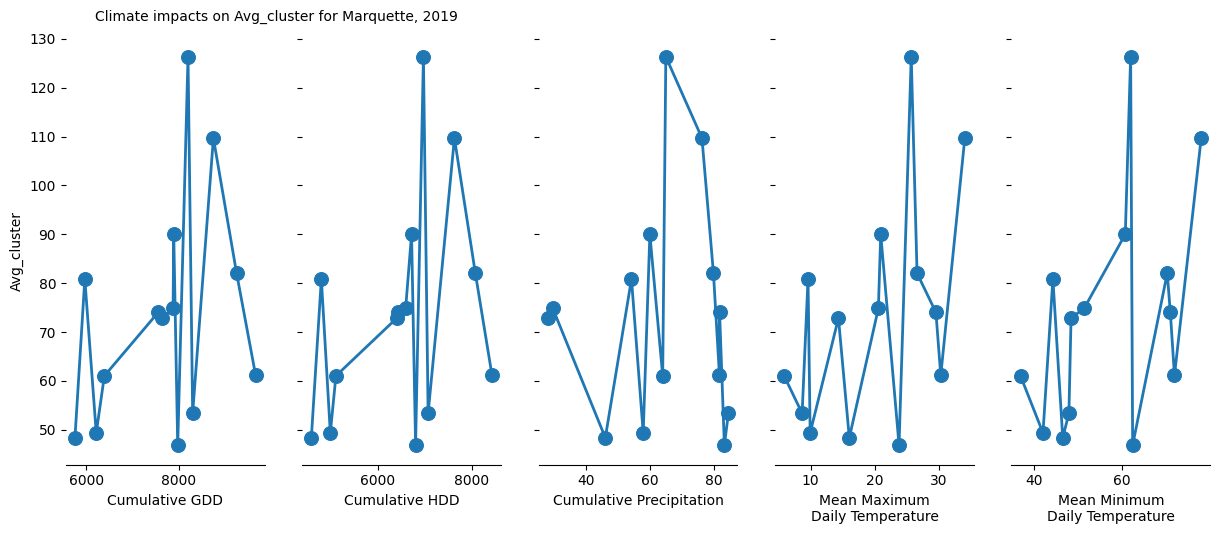

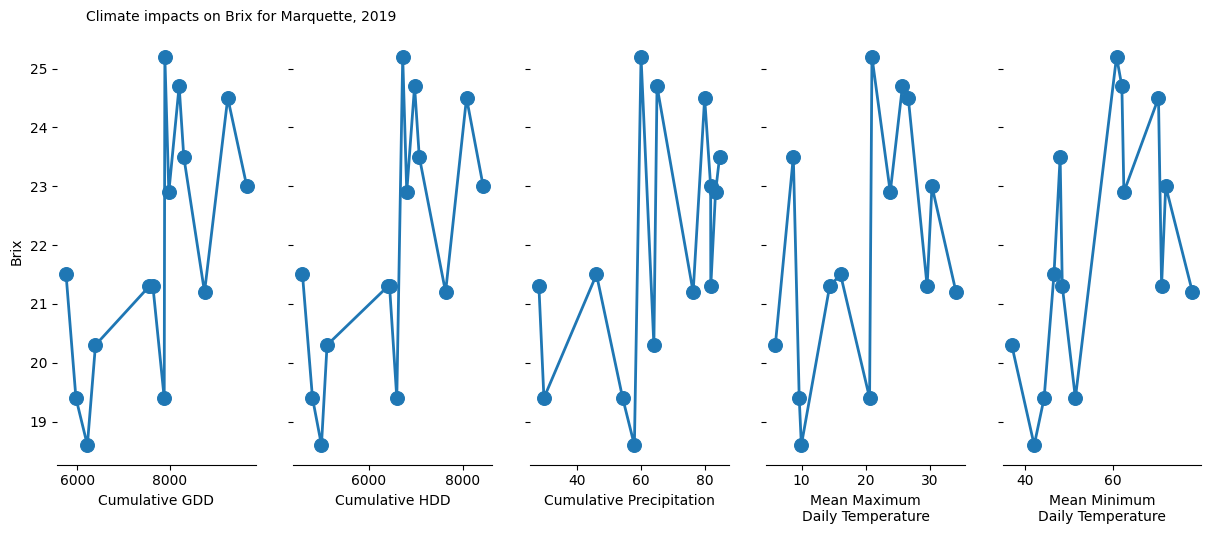

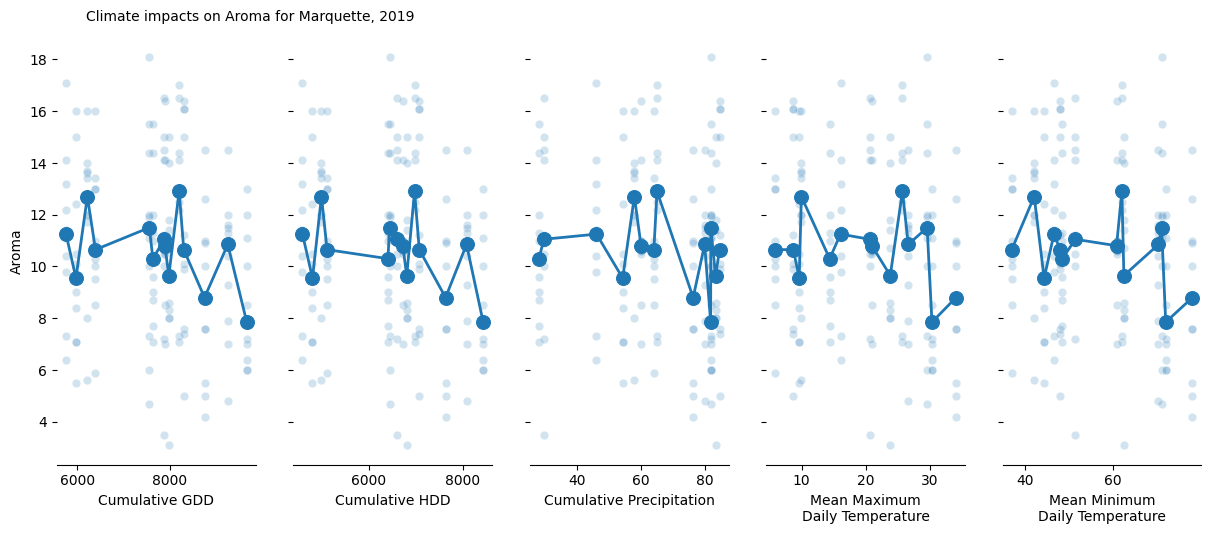

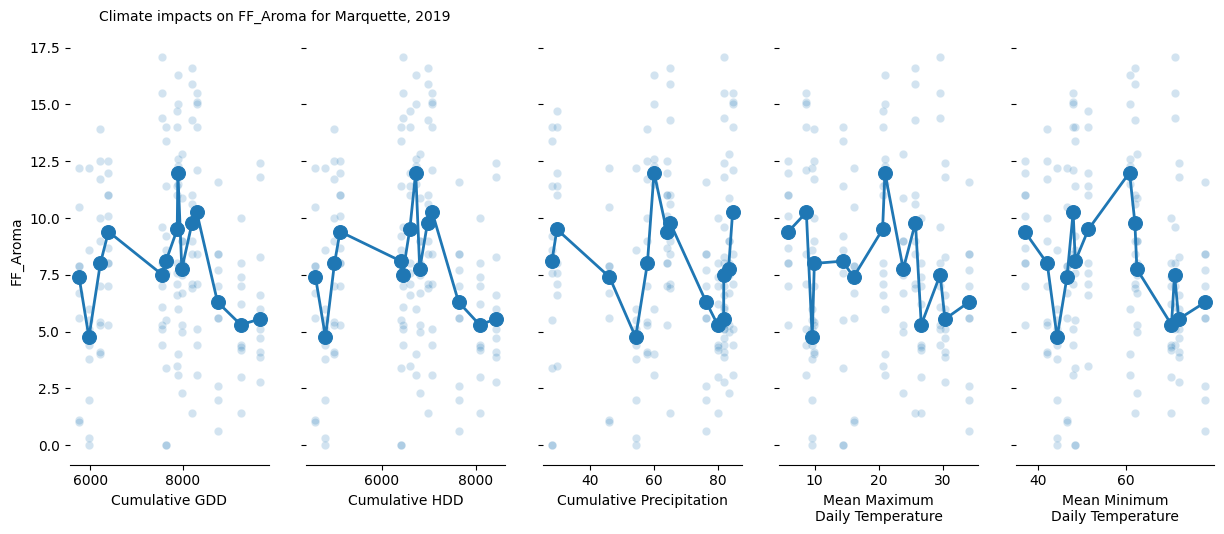

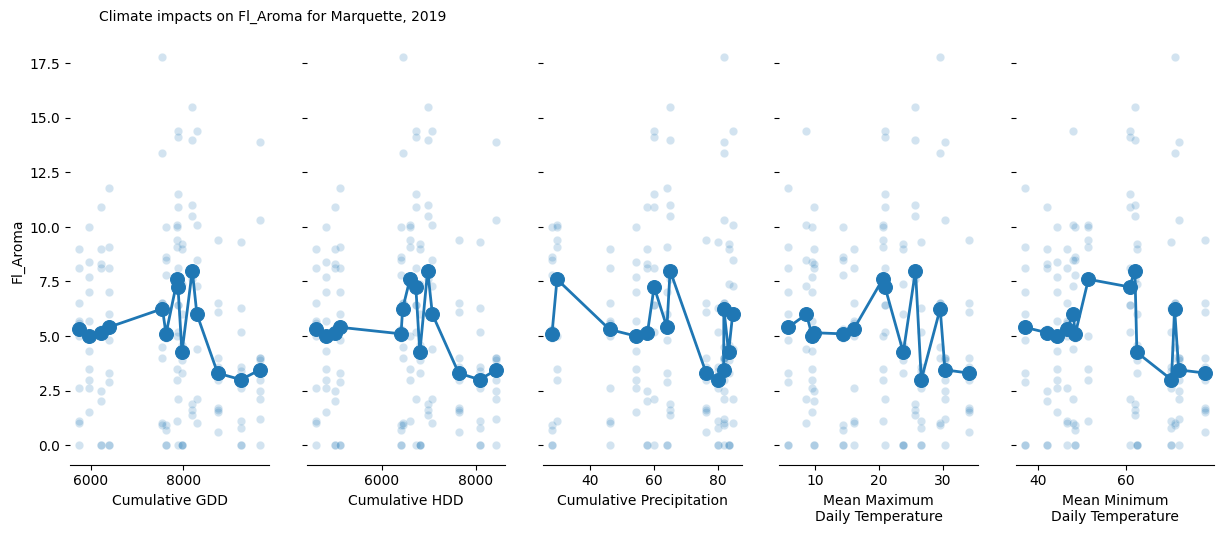

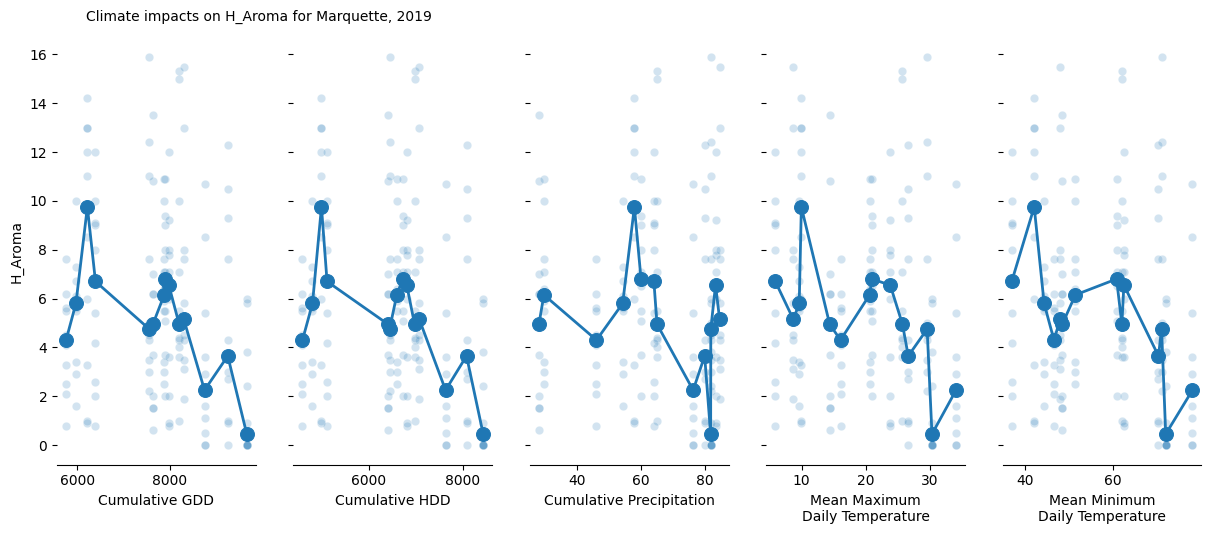

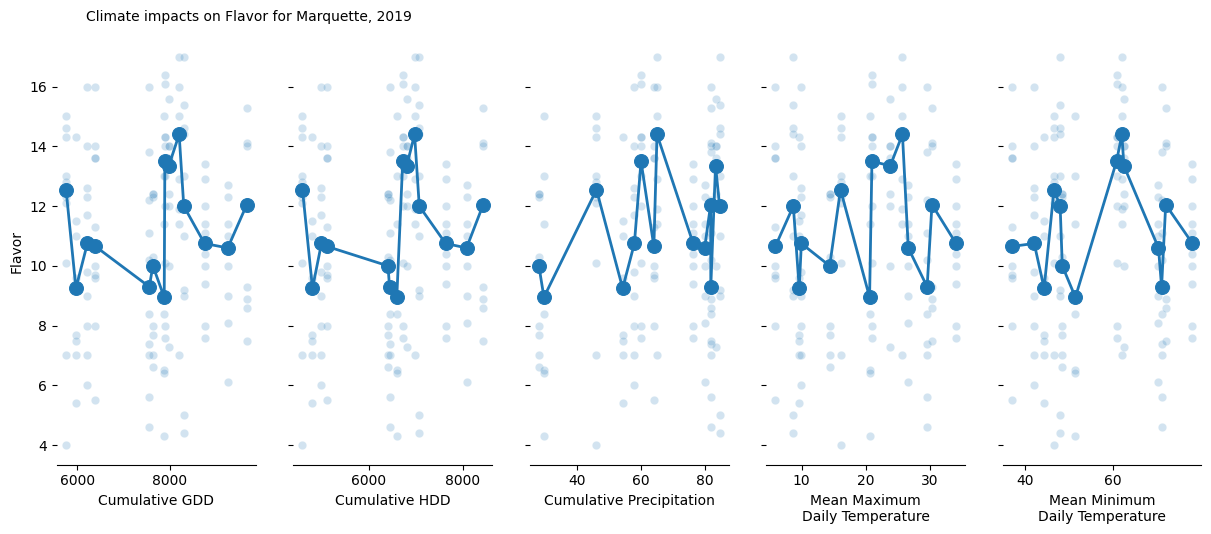

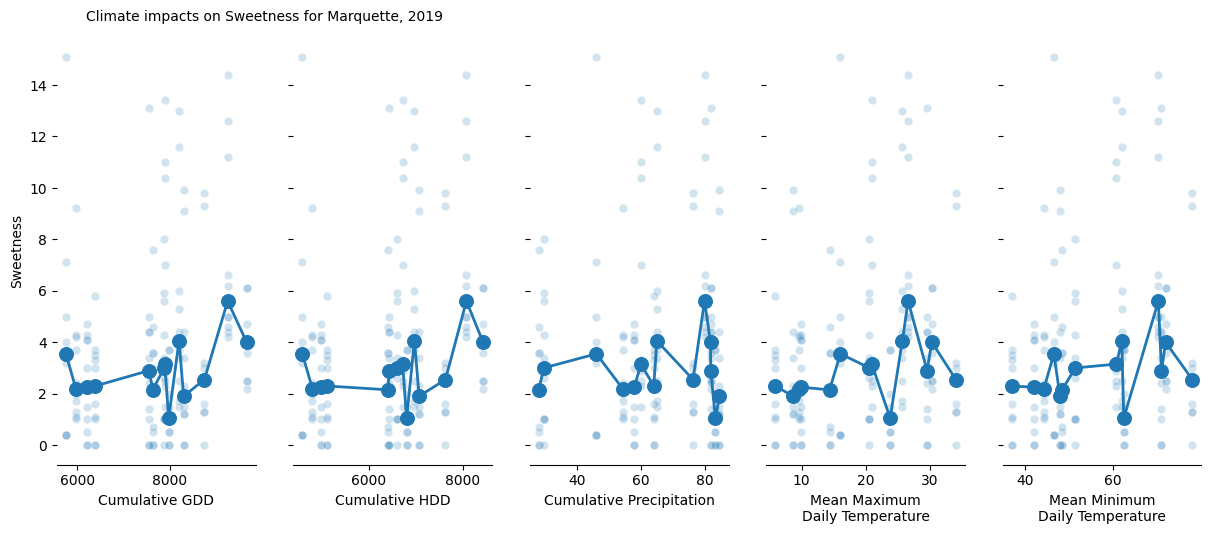

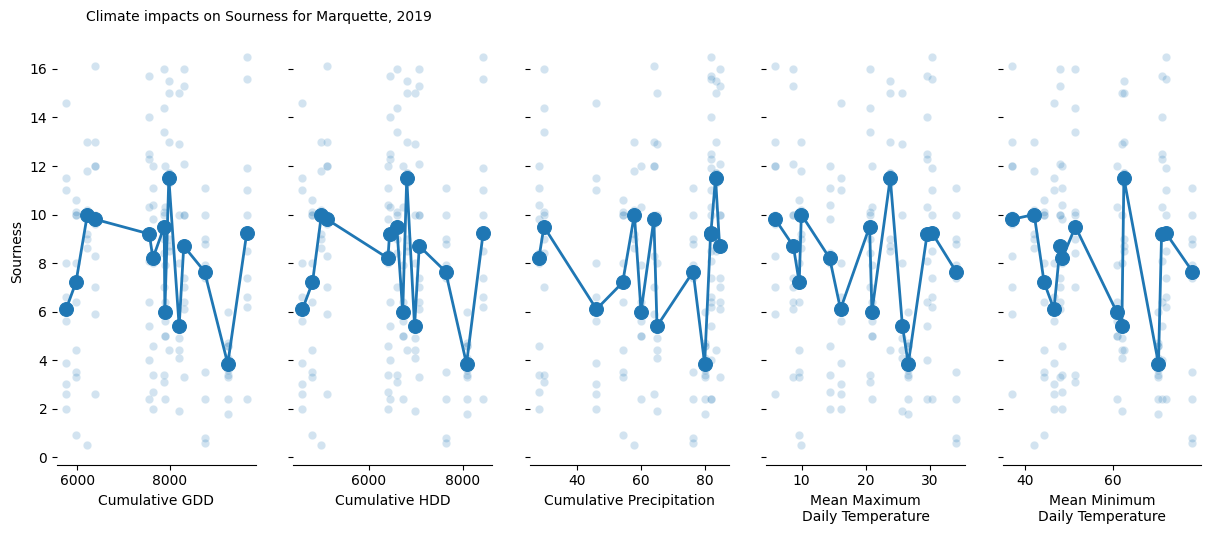

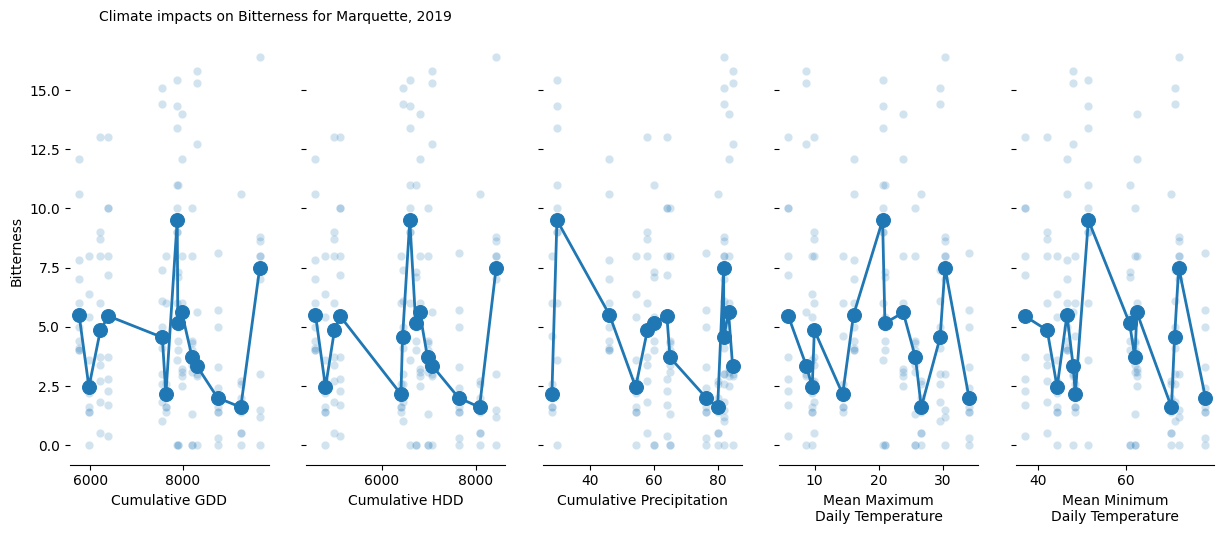

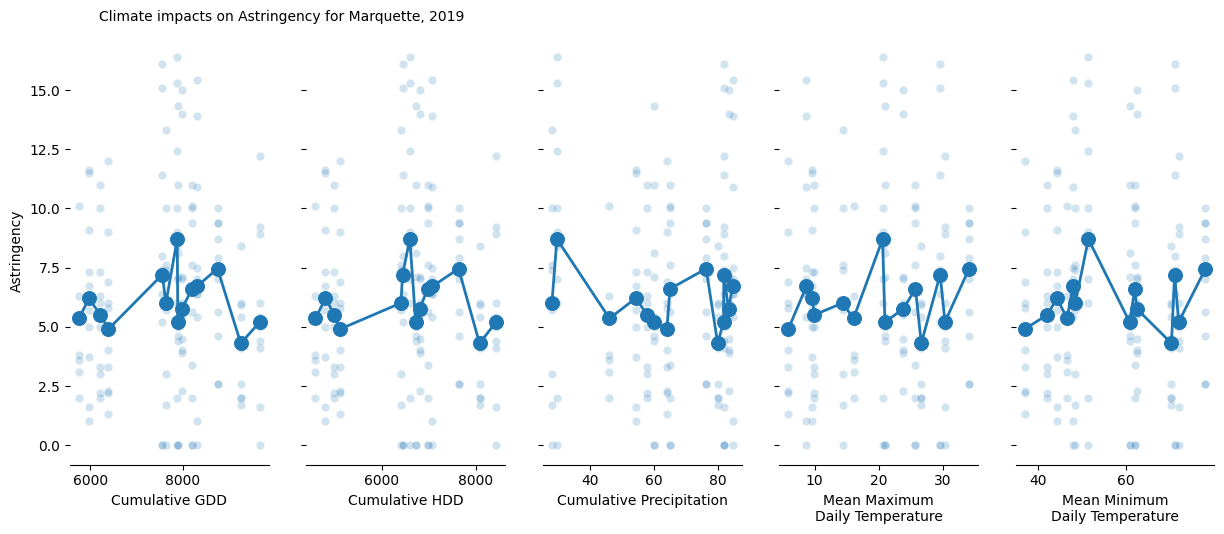

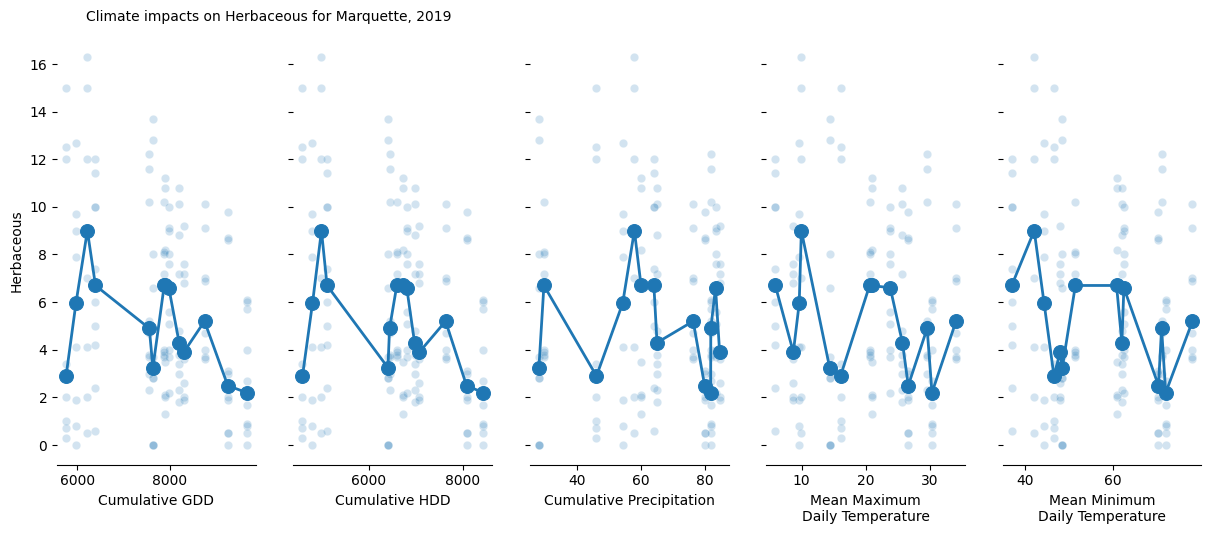

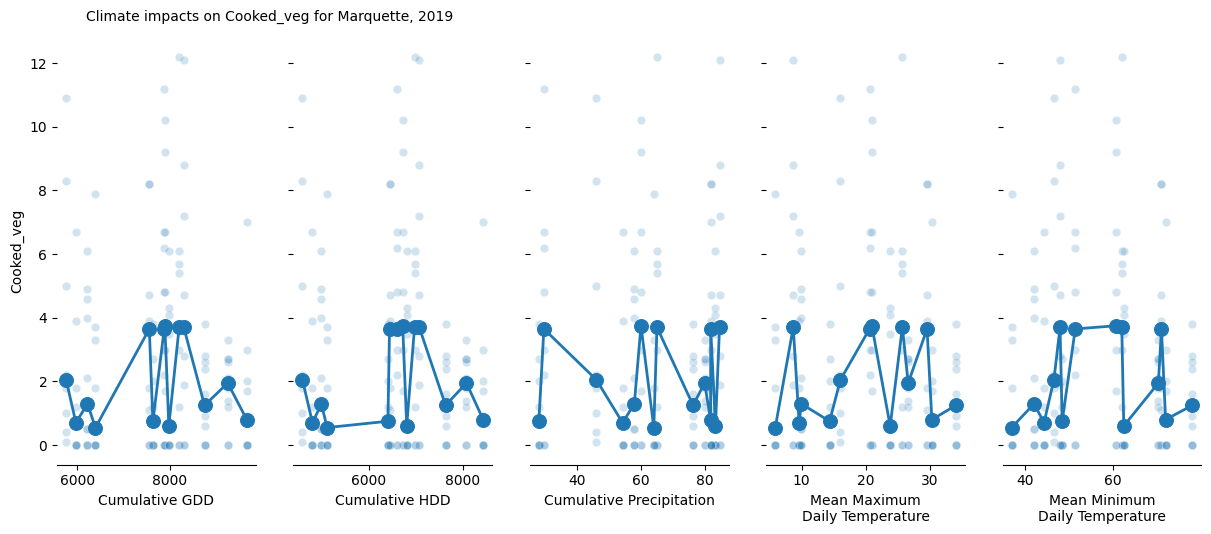

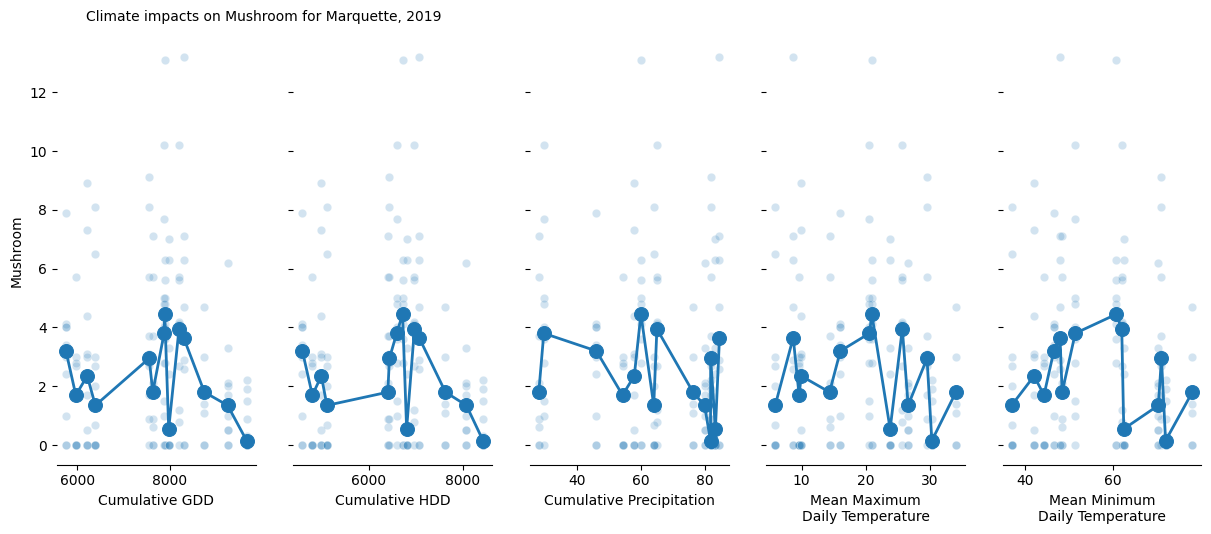

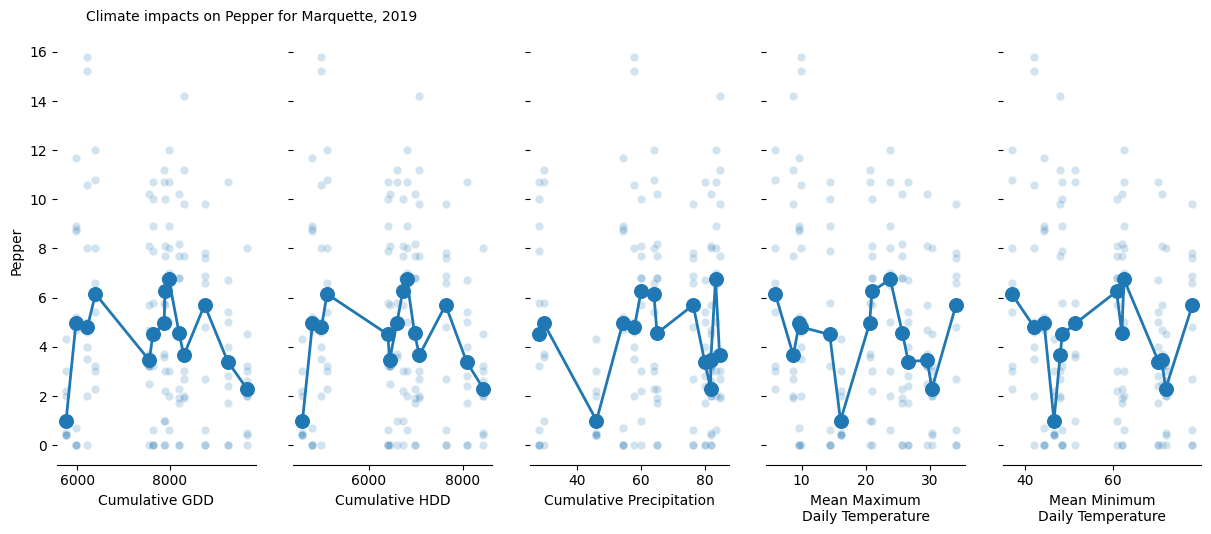

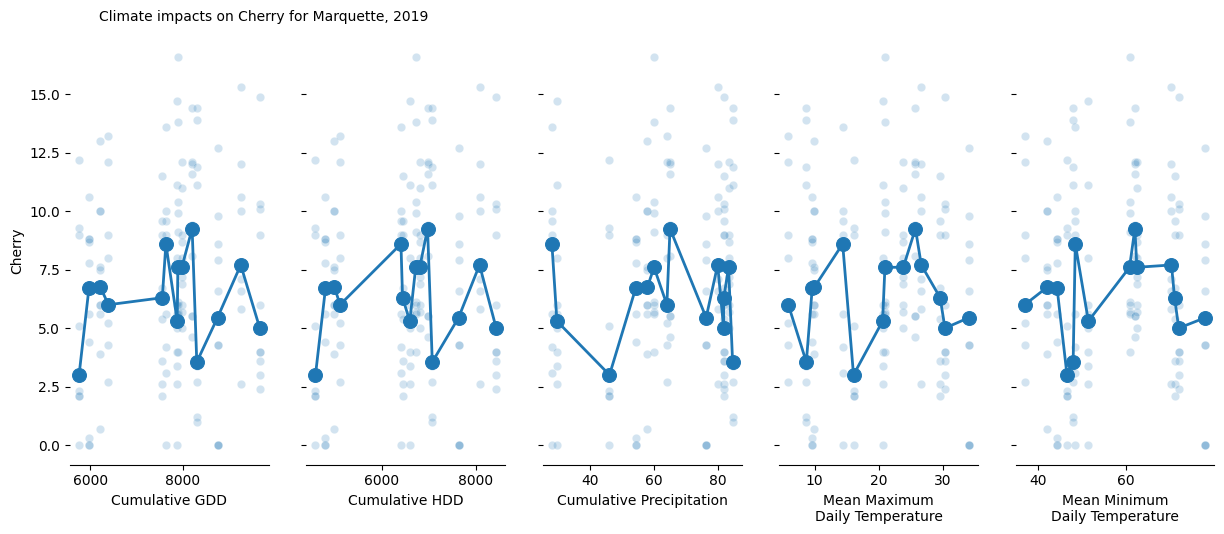

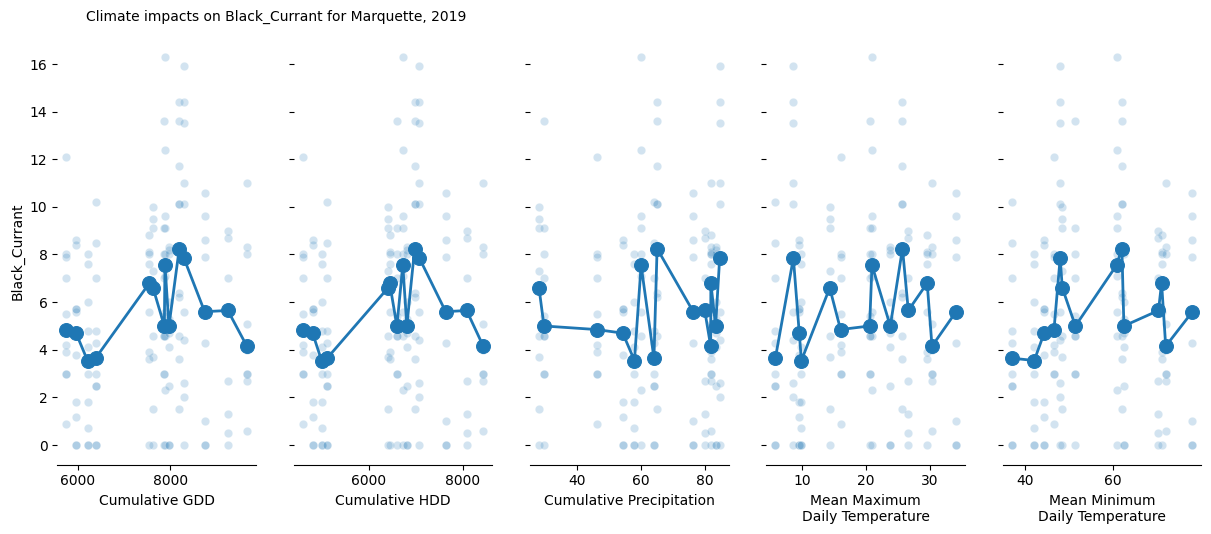

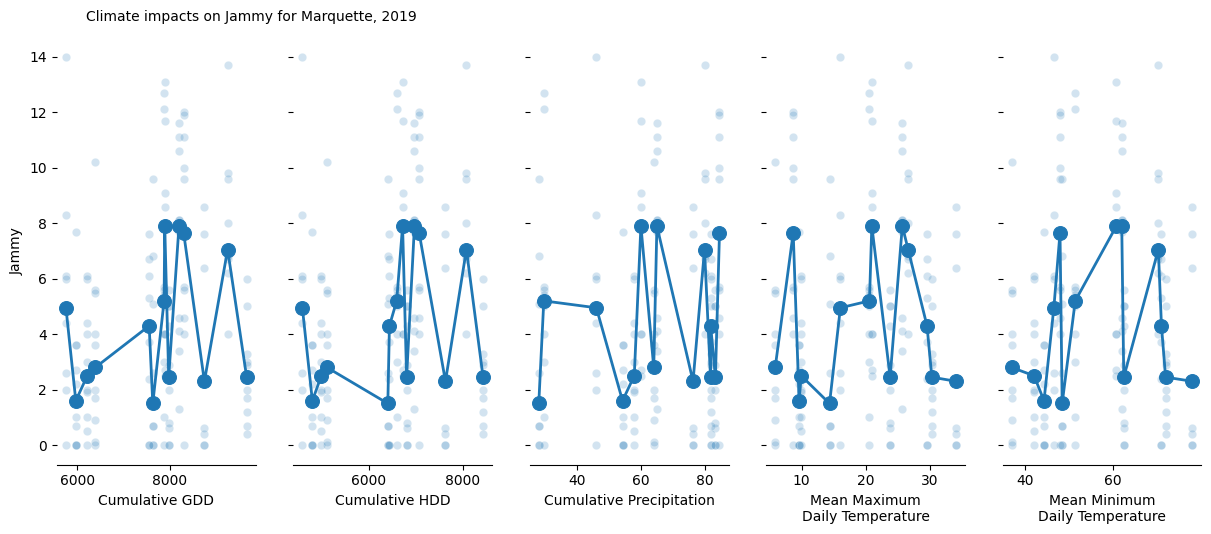

In [14]:
#Axis labels
labels = ['Cumulative GDD', 'Cumulative HDD', 'Cumulative Precipitation', 'Mean Maximum\nDaily Temperature', 'Mean Minimum\nDaily Temperature']
vars_of_interest = ['Avg_cluster', 'Brix', 'Aroma', 'FF_Aroma', 'Fl_Aroma', 'H_Aroma', 'Flavor', 'Sweetness', 'Sourness', 'Bitterness',
       'Astringency', 'Herbaceous', 'Cooked_veg', 'Mushroom',
       'Pepper', 'Cherry', 'Black_Currant', 'Jammy']
#categorical ones: 'Alcohol', 'Pleasing', 'Like', 'Ripeness'

for variable in vars_of_interest:
    #Correlation between Climate and Overall Flavor
    g = sns.PairGrid(all_data, y_vars=variable, palette = 'BuGn',
                    x_vars=["index_GDD_cum", "index_HDD_cum", "value_precip_cm", "value_maxTemp_C", "value_meanTemp_C"],
                    height=5, aspect=.5)

    # Draw a seaborn pointplot onto each Axes
    g.map(sns.scatterplot, alpha = 0.2)
    g.map(sns.lineplot, marker = 'o', markersize = 10, linewidth = 2, markeredgecolor = None,
        estimator = 'median', errorbar = None)

    for i, row in enumerate(g.axes):
        for j, ax in enumerate(row):
            if ax is not None:
                ax.set_xlabel(labels[j], fontsize = 10)

    g.figure.suptitle('Climate impacts on ' + variable + ' for Marquette, 2019', horizontalalignment = 'left', x = 0.08, y = 1.02, size = 10)
    sns.despine(fig=g.fig, left=True)
    #g.add_legend(title = ' ', bbox_to_anchor = (0.18,1.1))

    #save
    g.savefig('./figures/climate impact exploration/climateImpacts_' + variable + '.pdf', bbox_inches = 'tight')
    g.savefig('./figures/climate impact exploration/climateImpacts_' + variable + '.png', dpi = 300, bbox_inches = 'tight')
